In [18]:
using MarineHydro
import Meshes as Meshes
using CairoMakie: CairoMakie as Makie
using Unitful: m, ustrip, Length, u, @u_str
using LinearAlgebra: cross, dot, norm
using DifferentiationInterface 
import ForwardDiff 

In [9]:
function rectangular_lid_mesh(x_min::Real, x_max::Real, y_min::Real, y_max::Real, n_panels_x::Int, n_panels_y::Int, z_value::Real=0.0)
    # 1. Create a flat 2D CartesianGrid
    start_point = Meshes.Point(x_min, y_min)
    end_point   = Meshes.Point(x_max, y_max)
    grid = Meshes.CartesianGrid(start_point, end_point, dims=(n_panels_x, n_panels_y))

    # 2. Extract the 2D vertices and elevate them to 3D
    verts2d = Meshes.vertices(grid)
    verts3d = map(verts2d) do v
        vec_coords = Meshes.to(v)
        z_with_unit = z_value * u"m"
        Meshes.Point(vec_coords[1], vec_coords[2], z_with_unit)
    end

    # 3. Extract the connectivity indices natively from the grid elements
    # This unpacks the quad-panel connections explicitly
    connec = [Meshes.connect(Tuple(e.indices)) for e in Meshes.topology(grid)]

    # 4. Construct the SimpleMesh using an explicit unstructured configuration
    return Meshes.SimpleMesh(verts3d, connec)
end


rectangular_lid_mesh (generic function with 2 methods)

In [5]:
function generate_lid(x_min_lid::Real, x_max_lid::Real, y_min_lid::Real, y_max_lid::Real, z_value::Real, faces_max_radius::Real, show_lid::Bool=false)

    n_panels_x = Int(ceil((x_max-x_min)/(2*faces_max_radius)))
    n_panels_y = Int(ceil((y_max-y_min)/(2*faces_max_radius)))

    mesh = rectangular_lid_mesh(x_min_lid, x_max_lid, y_min_lid, y_max_lid, n_panels_x, n_panels_y, z_value)
    if show_lid
        fig = Makie.Figure()
        ax = Makie.Axis3(fig[1, 1], title = "Rectangular Lid Mesh", aspect = :data)
        Meshes.viz!(ax, mesh, color=:gold, showsegments=true, segmentcolor=:grey50, segmentsize=0.25)
        display(fig)
    end
    return Mesh(mesh)
end

function generate_lid(x_min_lid::Real, x_max_lid::Real, y_min_lid::Real, y_max_lid::Real, z_value::Real, faces_max_radius::Real)
    return generate_lid(x_min_lid, x_max_lid, y_min_lid, y_max_lid, z_value, faces_max_radius, false)
end



generate_lid (generic function with 2 methods)

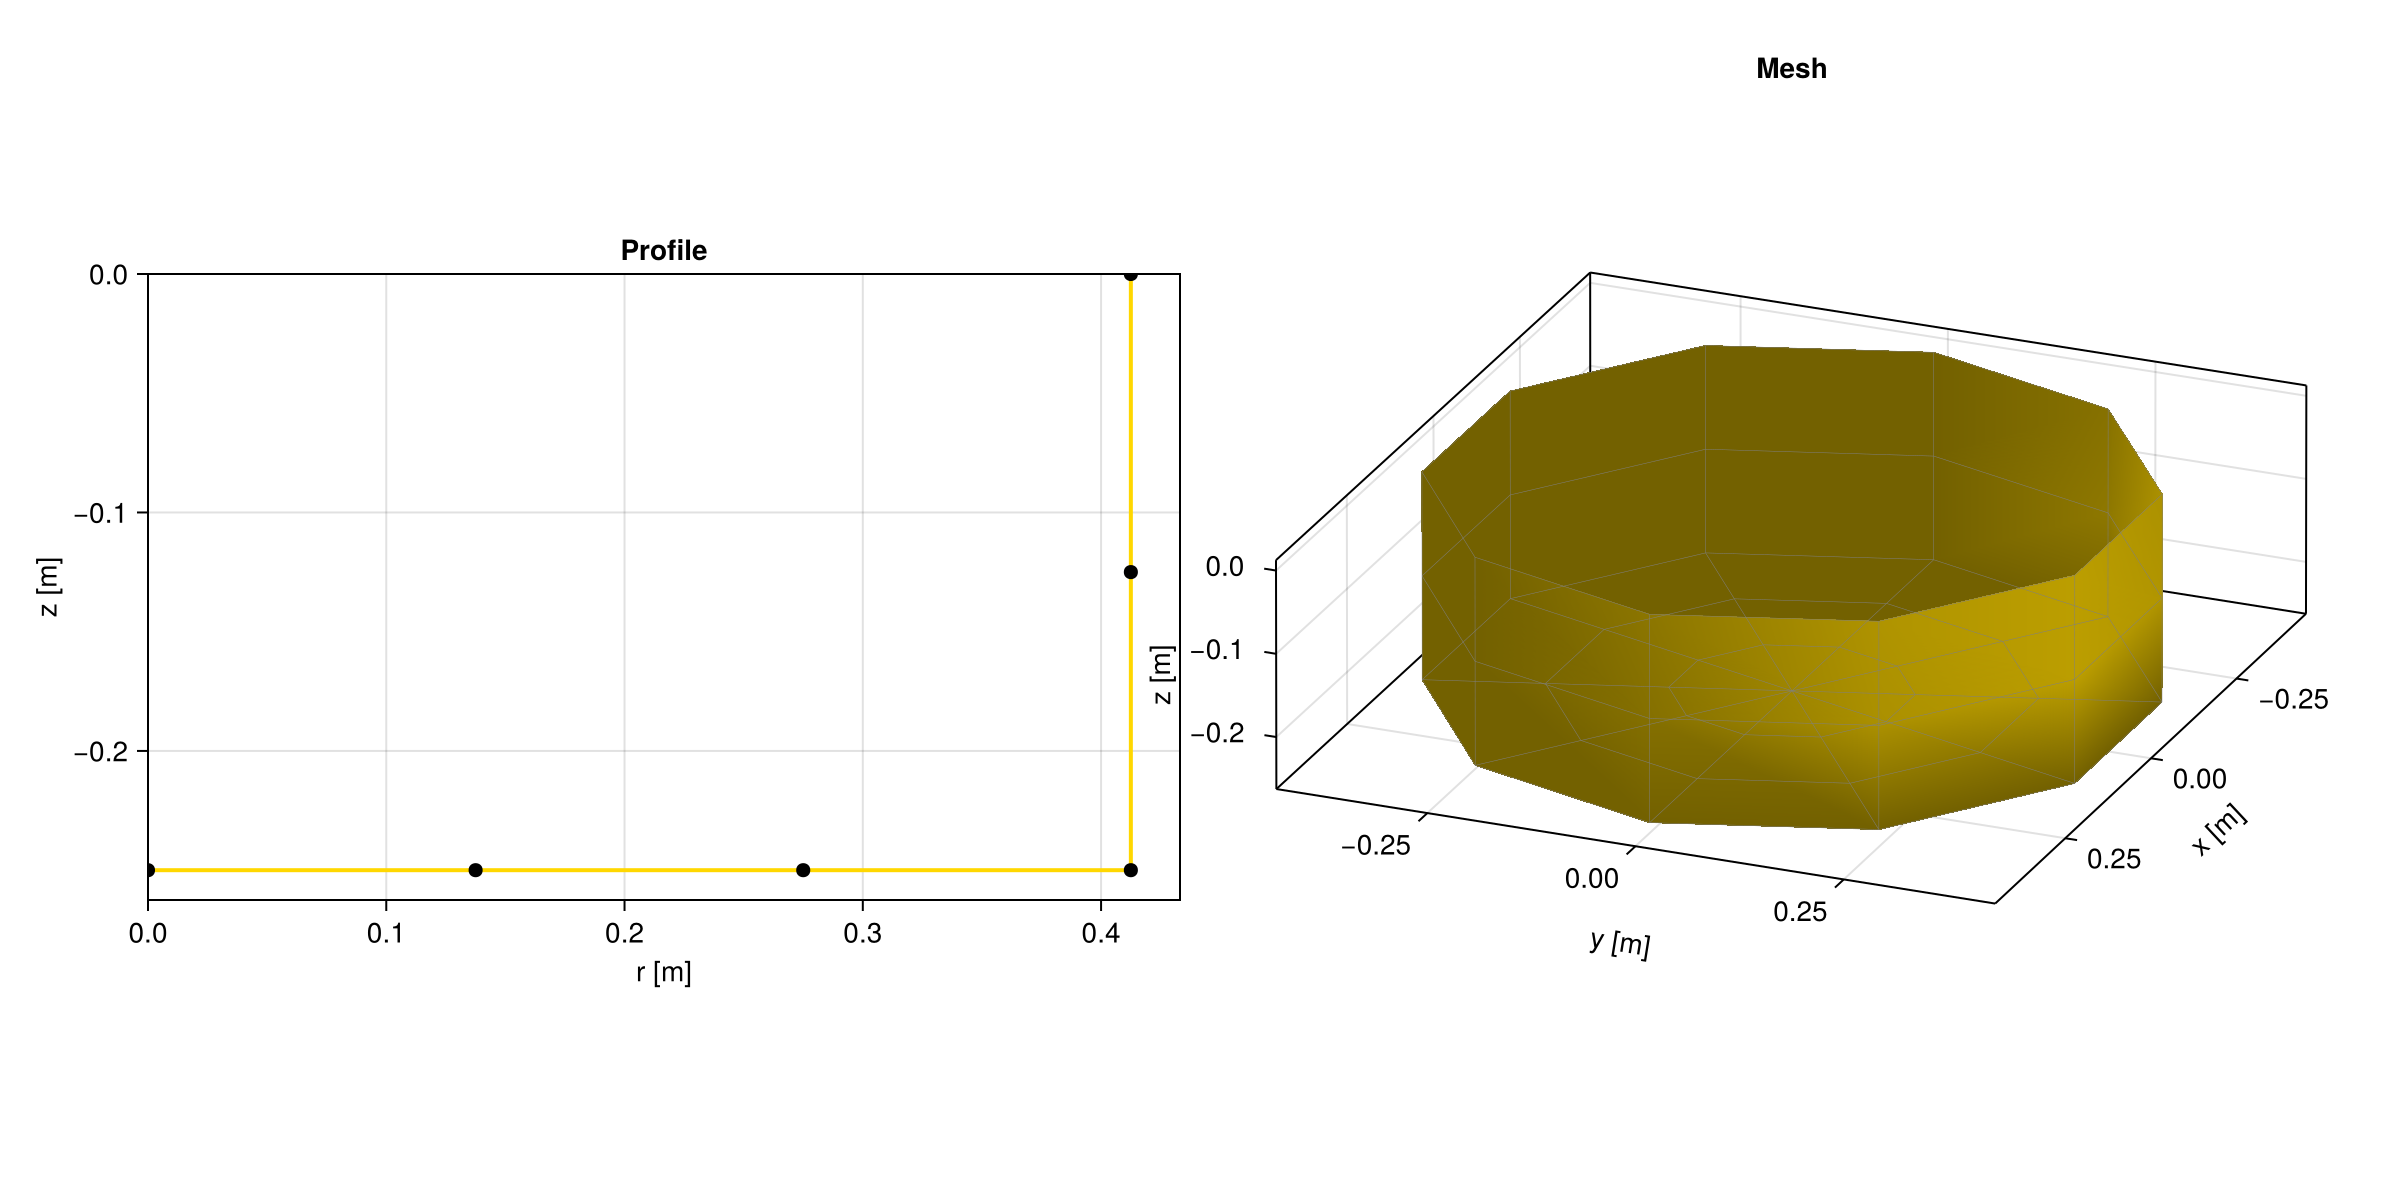

Mesh([0.41250000000000003 0.0 0.0; 0.33371951017966583 0.24246141657064518 0.0; … ; 0.11123983672655527 -0.0808204721902151 -0.25; 0.0 0.0 -0.25], [0 10 11 1; 1 11 12 2; … ; 48 50 49 49; 49 50 40 40], Number[0.37310975508983296 0.12123070828532258 -0.0625; 0.23059451017966584 0.31738611477119805 -0.0625; … ; 0.05124322448437017 -0.07053024772693291 -0.25; 0.08291327890885176 -0.026940157396738367 -0.25], Number[0.9510565162951536 0.30901699437494745 0.0; 0.5877852522924731 0.8090169943749476 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.031867377544916455, 0.03186737754491645, 0.031867377544916455, 0.03186737754491645, 0.031867377544916455, 0.03186737754491646, 0.03186737754491645, 0.03186737754491645, 0.031867377544916455, 0.03186737754491647  …  0.005556407463077286, 0.005556407463077286, 0.005556407463077286, 0.005556407463077286, 0.005556407463077287, 0.005556407463077286, 0.005556407463077284, 0.005556407463077286, 0.005556407463077286, 0.0055564074630772885], Number[0.1419673414044368

In [14]:
radii_upper = 1.0
radii_lower = 0.1
draft_upper = 2.0
draft_lower = 0.25



r_initial = 0.5
n_side = 4-1 # number of design vars-1 (draft is also a design var)

# inputs
# r_side = ones(n_side) * r_initial
# r_side = collect(range(0.5, 0.001, length=n_side)) # last radius cannot be zero
draft = draft_lower
r_side = ones(n_side) * (radii_upper+radii_lower)/2 * 0.75
# rad_ref = (radii_upper+radii_lower)/2 * 0.75
# r_side = collect(range(rad_ref*1.1, rad_ref*0.9, length=n_side))
x_val = vcat(r_side,draft)


function arbitrary_axisymmetric_mesh(x::Vector, show_plot)

    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)

    z_side = collect(range(-0.0, -draft, length=n_side))

    panel_z_len = abs(z_side[1]-z_side[2])
    last_z = z_side[end]

    n_bottom = 3

    z_bottom = ones(n_bottom) * (-draft)
    r_bottom = collect(range(r_side[end], 0.0, length=n_bottom+1))[2:end]

    z_vals = vcat(z_side, z_bottom)
    r_vals = vcat(r_side, r_bottom)

    n_theta = 10

    MH_mesh = axisymmetric_mesh(r_vals,z_vals,n_theta,show_plot)

    return MH_mesh
end

arbitrary_axisymmetric_mesh(x::Vector) = arbitrary_axisymmetric_mesh(x, false)

ax_mesh = arbitrary_axisymmetric_mesh(x_val, true)

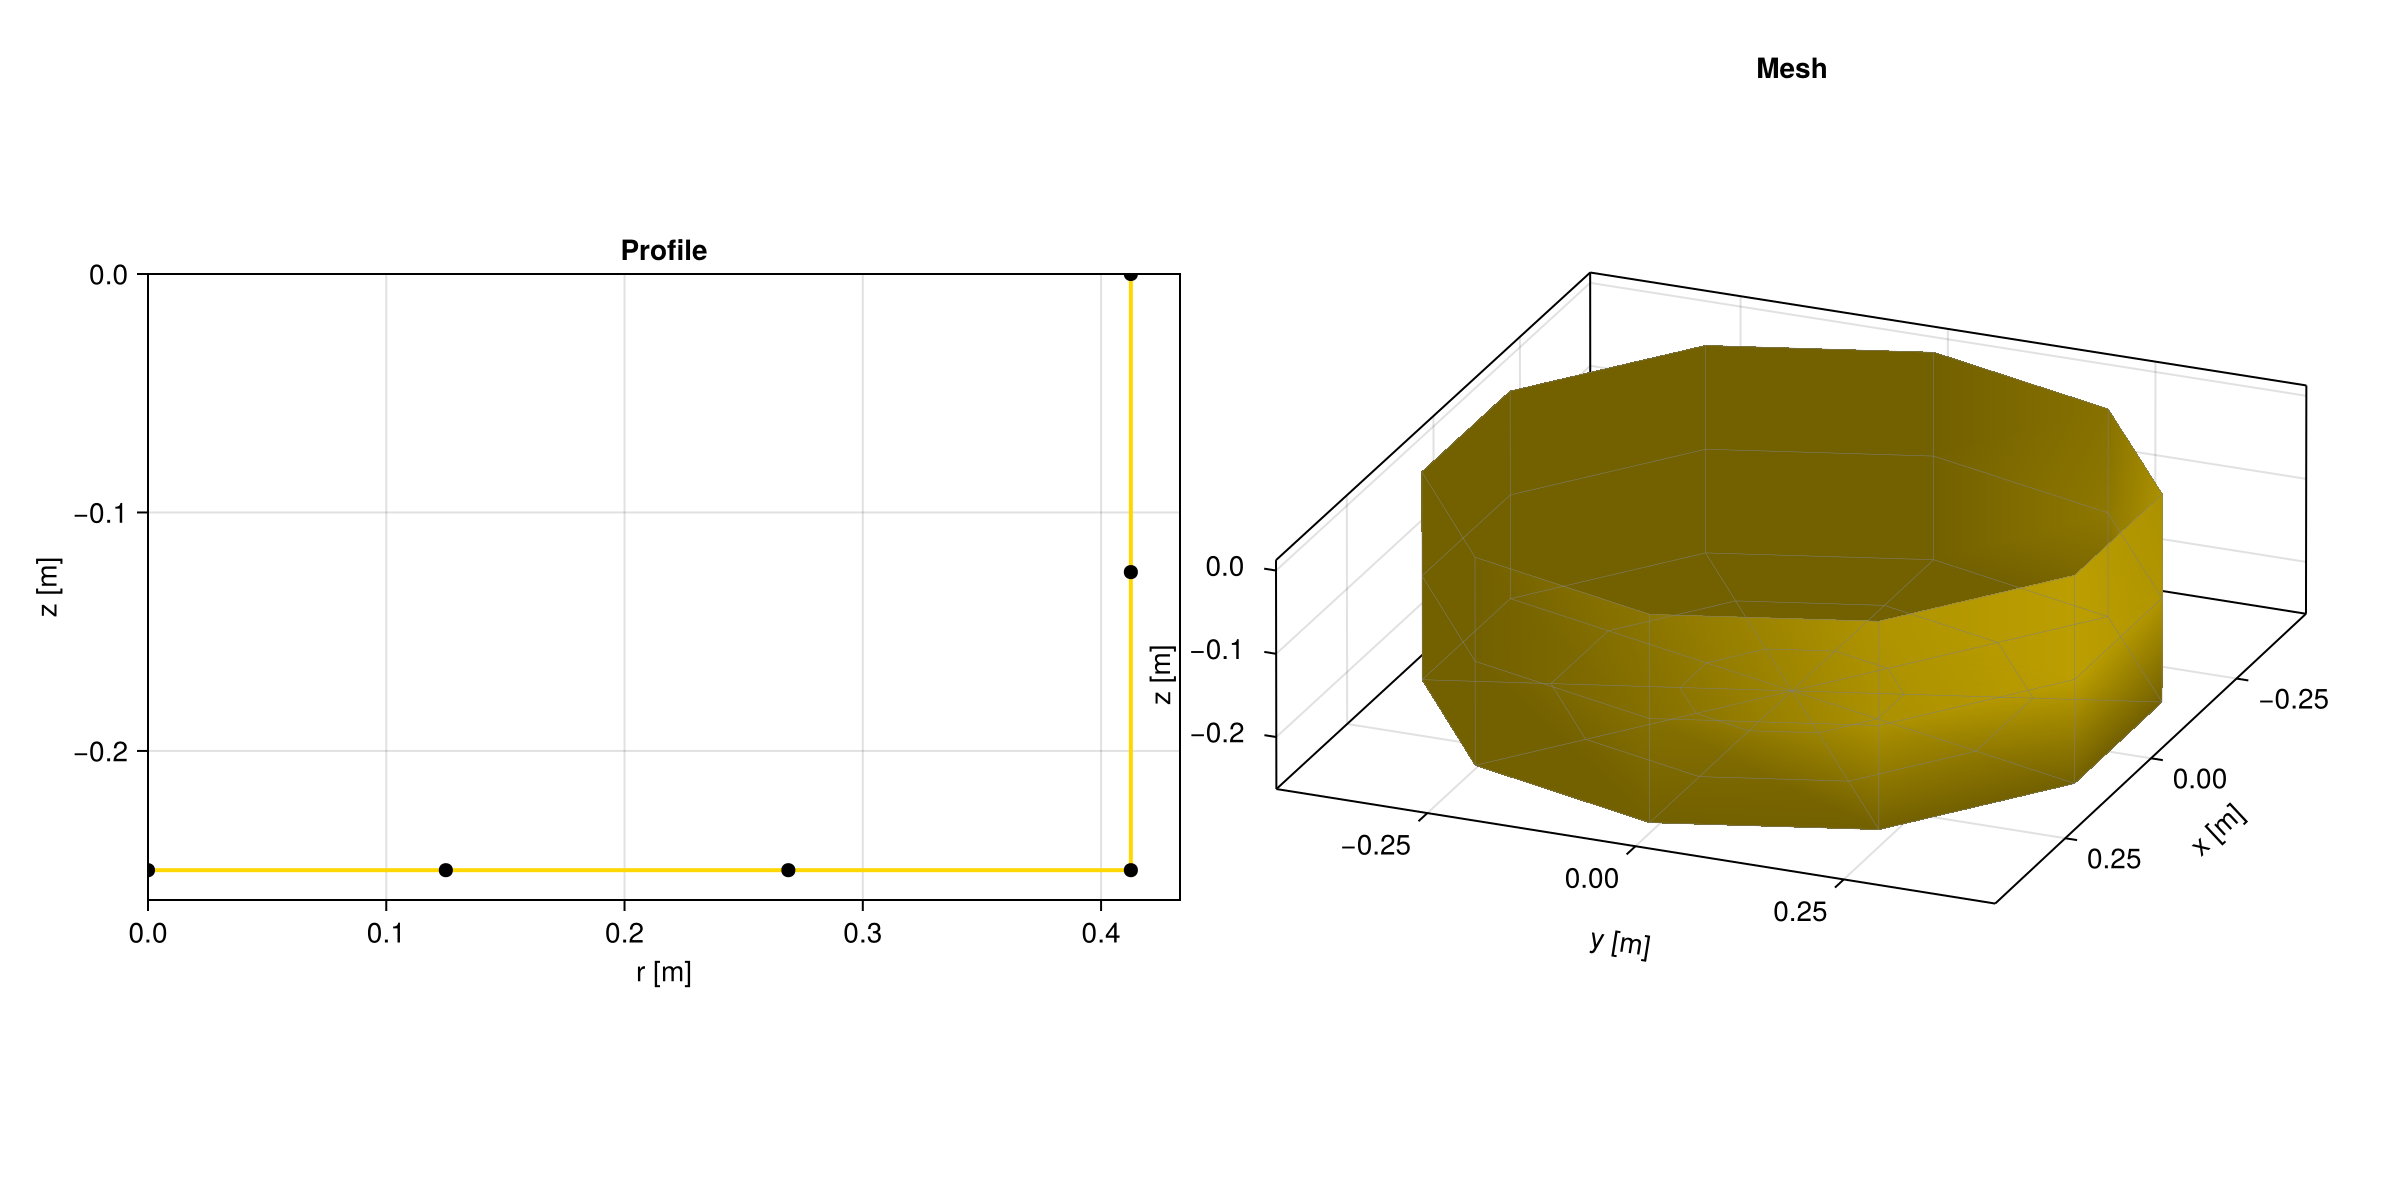

Mesh([0.41250000000000003 0.0 -0.0; 0.33371951017966583 0.24246141657064518 -0.0; … ; 0.10112712429686842 -0.07347315653655917 -0.25; 0.0 0.0 -0.25], [0 10 11 1; 1 11 12 2; … ; 48 50 49 49; 49 50 40 40], Number[0.37310975508983296 0.12123070828532258 -0.0625; 0.23059451017966584 0.31738611477119805 -0.0625; … ; 0.046584749531245605 -0.06411840702448446 -0.25; 0.07537570809895615 -0.024491052178853057 -0.25], Number[0.9510565162951536 0.30901699437494745 0.0; 0.5877852522924731 0.8090169943749476 0.0; … ; 0.0 0.0 -1.0; 0.0 0.0 -1.0], [0.031867377544916455, 0.03186737754491645, 0.031867377544916455, 0.03186737754491645, 0.031867377544916455, 0.03186737754491646, 0.03186737754491645, 0.03186737754491645, 0.031867377544916455, 0.03186737754491647  …  0.004592072283534946, 0.004592072283534946, 0.0045920722835349455, 0.004592072283534946, 0.004592072283534946, 0.004592072283534946, 0.004592072283534946, 0.0045920722835349455, 0.004592072283534946, 0.004592072283534948], Number[0.14196734140

In [15]:
r1 = r_side[1]
r2 = 0.125
d1 = draft
d2 = 0.0
n_points = (2, 3, 3)
n_theta = 10
show_plot = true


wb_mesh = wavebot_mesh(r1,r2,d1,d2,n_points,n_theta,show_plot)

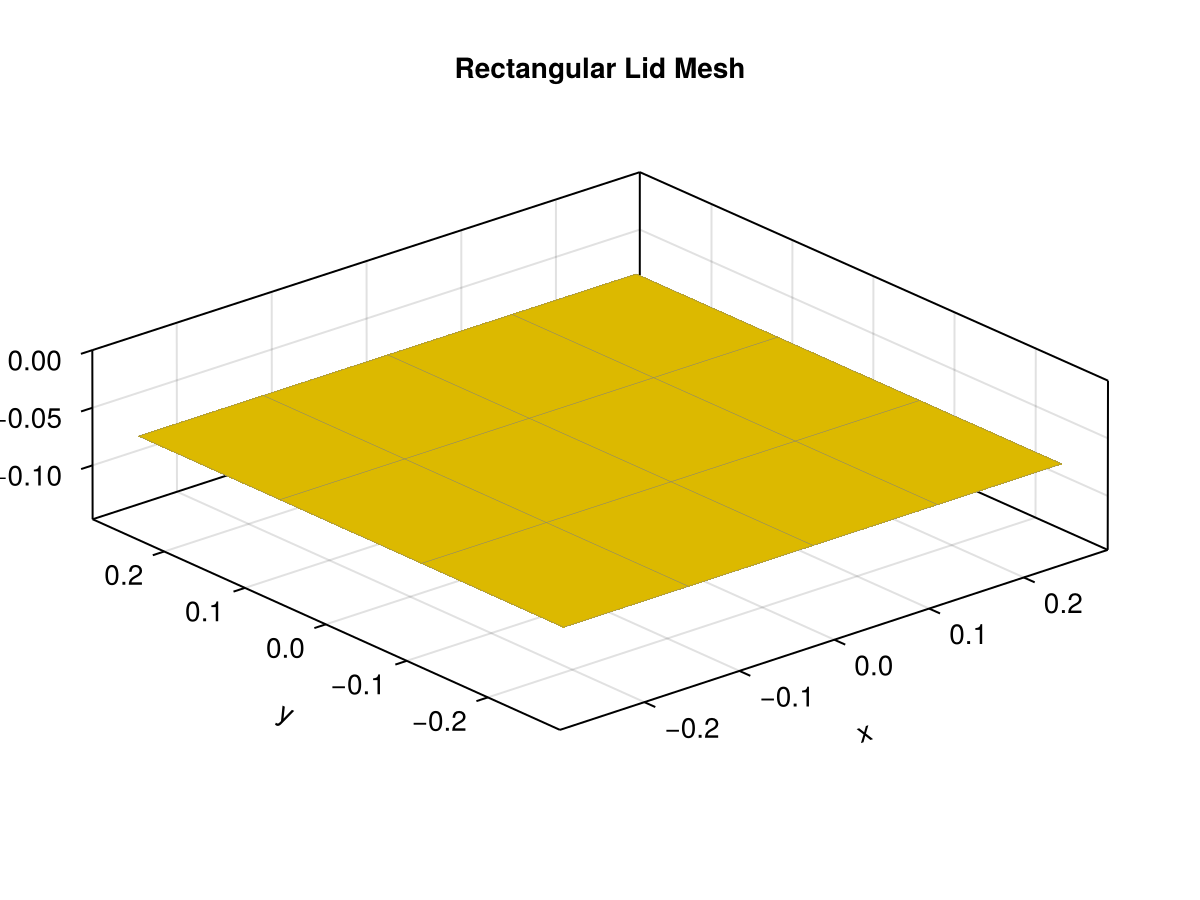

Mesh([-0.26251339251550576 -0.26251339251550576 -0.0734083; -0.13125669625775288 -0.26251339251550576 -0.0734083; … ; 0.13125669625775288 0.26251339251550576 -0.0734083; 0.26251339251550576 0.26251339251550576 -0.0734083], [0 1 6 5; 1 2 7 6; … ; 12 13 18 17; 13 14 19 18], Number[-0.19688504438662935 -0.1750089283436705 -0.0734083; -0.06562834812887644 -0.1750089283436705 -0.0734083; … ; 0.06562834812887644 0.17500892834367052 -0.0734083; 0.1968850443866293 0.17500892834367052 -0.0734083], Number[0.0 0.0 1.0; 0.0 0.0 1.0; … ; 0.0 0.0 1.0; 0.0 0.0 1.0], [0.02297109375, 0.02297109375, 0.02297109375, 0.02297109375, 0.02297109375, 0.02297109375, 0.02297109375, 0.02297109375, 0.022971093749999998, 0.022971093749999998, 0.022971093749999998, 0.022971093749999998], Number[0.10938058021479406, 0.10938058021479408, 0.10938058021479408, 0.10938058021479409, 0.10938058021479406, 0.10938058021479408, 0.10938058021479408, 0.10938058021479409, 0.10938058021479408, 0.10938058021479406, 0.1093805802147

In [58]:
radius_at_surface = maximum(r_side)
x_mean = 0.0
y_mean = 0.0
reduce_scale = 0.9
width = radius_at_surface * (2/sqrt(2)) * reduce_scale
x_min_lid = x_mean - width/2
x_max_lid = x_mean + width/2
y_min_lid = y_mean - width/2
y_max_lid = y_mean + width/2
z_value = -0.0734083
faces_max_radius = 1.4

lid_mesh = generate_lid(x_min_lid, x_max_lid, y_min_lid, y_max_lid, z_value, faces_max_radius,true)



In [19]:
# Hydrostatics
function hydrostatic_program(x)
    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)
    
    z_side = range(-1e-3, -draft, length=n_side)

    rho_w = 1025.0 
    g = 9.81 
    K = rho_w * g * pi * r_side[1]^2 


    volume = 0.0
    for i in 1:(n_side-1)
        h_mid = abs(z_side[i] - z_side[i+1])
        r1 = r_side[i]
        r2 = r_side[i+1]

        volume += (pi * h_mid / 3) * (r1^2 + r1 * r2 + r2^2)
    end
    
    M = rho_w * volume 

    return [M, K]
end

# Radiation
function radiation_program(mesh, omega, dof) 
    A, B = calculate_radiation_forces(mesh,dof,omega)
    # display("Damping: $B")
    return [A, B]
end

# Diffraction
function diffraction_program(mesh, omega, dof) 
    F_D = DiffractionForce(mesh,omega,dof)
    return [real(F_D),imag(F_D)]
end

function incident_program(mesh, omega, dof) 
    F_FK = FroudeKrylovForce(mesh,omega,dof)
    return [real(F_FK),imag(F_FK)]
end

# Everything
dof = [0.0,0.0,1.0]

function compute_for_omega(mesh, omega)

    # M, K = hydrostatic_program(r1, r2, d1, d2)
    A, B = radiation_program(mesh, omega, dof)
    F_D_real, F_D_imag = diffraction_program(mesh, omega, dof) 
    F_FK_real, F_FK_imag = incident_program(mesh, omega, dof)
    # add negatives to imag since wot uses +i omega t instead of -i omega t
    return [A, B, F_D_real, -F_D_imag, F_FK_real, -F_FK_imag]
end

backend = AutoForwardDiff()


function arbitrary_axisymmetric_mesh(x, show_plot)

    r_side = x[1:end-1]
    draft = x[end]
    n_side = length(r_side)

    z_side = collect(range(-1e-3, -draft, length=n_side))

    panel_z_len = abs(z_side[1]-z_side[2])
    last_z = z_side[end]

    n_bottom = 3

    z_bottom = ones(n_bottom) * (-draft)
    r_bottom = collect(range(r_side[end], 0.0, length=n_bottom+1))[2:end]

    z_vals = vcat(z_side, z_bottom)
    r_vals = vcat(r_side, r_bottom)

    n_theta = 10

    MH_mesh = axisymmetric_mesh(r_vals,z_vals,n_theta,show_plot)

    return MH_mesh
end

arbitrary_axisymmetric_mesh(x) = arbitrary_axisymmetric_mesh(x, false)


function compute_vals(x, omegas)
    set_rho!(1025.0)
    x=vec(x)
    mesh = arbitrary_axisymmetric_mesh(x)    
    M_val, K_val = hydrostatic_program(x)
    results_per_omega = [compute_for_omega(mesh, omega) for omega in omegas]
    vec_reduced = reduce(vcat, results_per_omega)
    
    return [M_val; K_val; vec_reduced]
end

function compute_all(x_val, omegas)
    return value_and_jacobian(x -> compute_vals(x, omegas), backend, x_val)
end


function surface_area(x)
    MH_mesh = arbitrary_axisymmetric_mesh(x)
    return sum(MH_mesh.areas)
end


function centers(x)
    MH_mesh = arbitrary_axisymmetric_mesh(x)
    return sum(abs.(MH_mesh.centers[:,1]))
end

function compute_SA_and_gradient(x_val)
    return value_and_gradient(x -> surface_area(x), backend, x_val)
end

compute_SA_and_gradient (generic function with 1 method)

In [59]:
using Plots

omega = 2*pi*0.3
num_omegas = 20
omegas = collect(range(omega/2,6*omega,length=num_omegas))
betas = [0.0]

rigid_dof_list = ["Heave"]
rotation_center = [0.0,0.0,0.0]

parameters = (wave_frequencies=omegas, 
    wave_directions=betas,
    radiating_dofs=Symbol.(rigid_dof_list),
    influenced_dofs=Symbol.(rigid_dof_list))

# No lid
floatingbody_no_lid = FloatingBody(ax_mesh, rigid_dof_list, rotation_center, "axisymmetric_fb")
mhresults_no_lid = compute_hydrodynamic_coefficients(parameters, floatingbody_no_lid)

# With lid
floatingbody_with_lid = FloatingBody(ax_mesh, lid_mesh, rigid_dof_list, rotation_center, "axisymmetric_fb_with_lid")
mhresults_with_lid = compute_hydrodynamic_coefficients(parameters, floatingbody_with_lid)


(added_mass = [160.69902399180882;;; 158.8555888630482;;; 151.35138645394912;;; … ;;; 117.16271076572603;;; 117.74228275061745;;; 118.33345956820388;;;;], radiation_damping = [9.597423404965493;;; 32.09191129048912;;; 64.61849803956217;;; … ;;; 0.18675508633861712;;; 1.023246690404536;;; 0.19563740221651982;;;;], diffraction_force = ComplexF64[-140.89140916403827 - 9.049692702245597im -340.49763957120024 - 47.89846099808298im … 54.567927618097436 + 10.963511271636285im 68.71870047769687 + 2.189375772857267im;;;;], Froude_Krylov_force = ComplexF64[4795.206326692022 + 6.106226635438361e-16im 4632.0985236753995 + 2.7755575615628914e-15im … -35.56858563611693 - 7.993605777301127e-15im -30.246737870952167 - 8.881784197001252e-15im;;;;], excitation_force = ComplexF64[4654.314917527984 - 9.049692702245597im 4291.600884104199 - 47.89846099808298im … 18.999341981980507 + 10.963511271636278im 38.471962606744704 + 2.1893757728572583im;;;;])

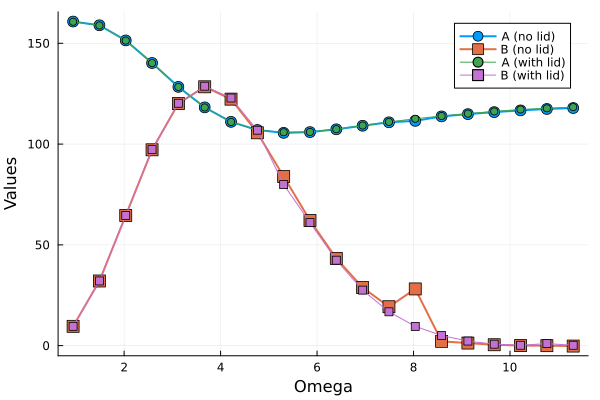

In [63]:
plot(omegas, vec(mhresults_no_lid.added_mass),
    label="A (no lid)", xlabel="Omega", ylabel="Values",
    linewidth=2, marker=:circle, markersize = 6)
plot!(omegas, vec(mhresults_no_lid.radiation_damping),
    label="B (no lid)", linewidth=2, marker=:square, markersize = 6)
plot!(omegas, vec(mhresults_with_lid.added_mass),
    label="A (with lid)", linewidth=1, marker=:circle, markersize = 4)
plot!(omegas, vec(mhresults_with_lid.radiation_damping),
    label="B (with lid)", linewidth=1, marker=:square, markersize = 4)

In [57]:
using PyCall
cpt = pyimport("capytaine")

cpt_mesh = cpt.mesh_vertical_cylinder(
    length=draft*2, radius=radius_at_surface, center=(0, 0, 0), faces_max_radius=faces_max_radius/2,
    ).immersed_part()
cpt_lid_mesh = cpt_mesh.generate_lid(z=cpt_mesh.lowest_lid_position(omega_max=maximum(omegas)))
width_of_lid = 2*maximum(cpt_lid_mesh.vertices[:,1])
println("Width of lid: $width_of_lid")
println("Z depth: $(cpt_lid_mesh.vertices[1,1])")


Width of lid: 0.5445000000000001
Z depth: -0.2722500000000001


In [ ]:
# Make one big compute function























